<a href="https://colab.research.google.com/github/SirLousy/LIS4693/blob/main/lab-4/lab-4-LL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import zipfile

url = "https://github.com/SirLousy/LIS4693/raw/refs/heads/main/lab-4/train.csv.zip"

r = requests.get(url)
open("dataset.zip", "wb").write(r.content)

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

In [3]:
import os
os.listdir()

['.config', 'train.csv', 'test.csv', 'dataset.zip', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
df["text"] = df["Title"] + " " + df["Description"]

X = df["text"]
y = df["Class Index"]

The Title and Description columns contain the news article text, so they were combined into a single text column to provide more context for the machine learning model. This combined column is used as the feature input. The Class Index column is used as the target label because it represents the category of the news article. The goal of the classifier is to learn patterns in the text and predict the correct news category.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [8]:
vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

The dataset was split into training and testing sets using a 70/30 ratio. The training data is used for the model to learn patterns, while the testing data is used to evaluate performance. TF-IDF vectorization was used to convert the text data into numerical values so machine learning algorithms can process it.

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [10]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    print(name)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print("Precision:", precision_score(y_test, predictions, average="weighted"))
    print("Recall:", recall_score(y_test, predictions, average="weighted"))
    print("F1:", f1_score(y_test, predictions, average="weighted"))
    print()

Naive Bayes
Accuracy: 0.9010833333333333
Precision: 0.9006632582763003
Recall: 0.9010833333333333
F1: 0.9007659616856358

Logistic Regression
Accuracy: 0.9127222222222222
Precision: 0.9126081673712388
Recall: 0.9127222222222222
F1: 0.9125756083794013

SVM
Accuracy: 0.9090277777777778
Precision: 0.9088580308798967
Recall: 0.9090277777777778
F1: 0.908850158043034



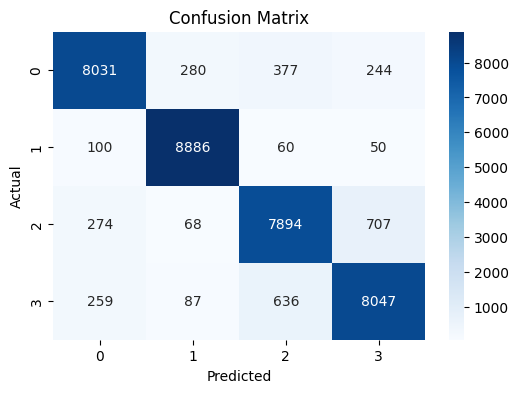

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf, y_train)

predictions = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

The Logistic Regression model performed the best among the three classifiers based on the evaluation metrics. It achieved the highest accuracy, precision, recall, and F1 score when predicting the news categories. The confusion matrix shows how the model’s predictions compare to the actual labels. The diagonal values represent correct predictions where the model identified the correct news category. The other values represent misclassifications where the model predicted the wrong category. Overall, most predictions fall along the diagonal, indicating the classifier performs well on this dataset.

In [12]:
import pandas as pd
import random

titles = [
"Tech companies expand AI research",
"Local team wins championship",
"New smartphone released by major brand",
"Scientists discover new planet",
"Stock markets rise after earnings report",
"Government announces economic policy",
"New medical breakthrough announced",
"Sports league announces new season schedule",
"Tech startup raises millions in funding",
"Scientists develop new renewable energy method"
]

descriptions = [
"Experts say the development could change the industry.",
"Fans celebrated after the major victory.",
"Analysts are closely watching the market reaction.",
"Researchers say the discovery could have major impact.",
"Officials discussed the plan during a press conference.",
"The innovation could improve future technologies.",
"The team dominated throughout the match.",
"Investors responded positively to the announcement.",
"The research was published earlier this week.",
"Experts believe the technology could expand rapidly."
]

rows = []

for i in range(100):
    rows.append({
        "Title": random.choice(titles),
        "Description": random.choice(descriptions),
        "Class Index": ""
    })

pseudo = pd.DataFrame(rows)

pseudo.to_csv("pseudo_news.csv", index=False)

pseudo.head()

,Title,Description,Class Index
0,Local team wins championship,The innovation could improve future technologies.,
1,Government announces economic policy,Experts believe the technology could expand ra...,
2,Government announces economic policy,Experts believe the technology could expand ra...,
3,Sports league announces new season schedule,The team dominated throughout the match.,
4,Government announces economic policy,Experts say the development could change the i...,


In [13]:
pseudo["text"] = pseudo["Title"] + " " + pseudo["Description"]

pseudo_tfidf = vectorizer.transform(pseudo["text"])

pseudo["Predicted"] = best_model.predict(pseudo_tfidf)

pseudo.head()

,Title,Description,Class Index,text,Predicted
0,Local team wins championship,The innovation could improve future technologies.,,Local team wins championship The innovation co...,2
1,Government announces economic policy,Experts believe the technology could expand ra...,,Government announces economic policy Experts b...,3
2,Government announces economic policy,Experts believe the technology could expand ra...,,Government announces economic policy Experts b...,3
3,Sports league announces new season schedule,The team dominated throughout the match.,,Sports league announces new season schedule Th...,2
4,Government announces economic policy,Experts say the development could change the i...,,Government announces economic policy Experts s...,3


In [14]:
pseudo.to_csv("predicted.csv", index=False)

In [15]:
pseudo[["Title", "Description", "Predicted"]].head(10)

,Title,Description,Predicted
0,Local team wins championship,The innovation could improve future technologies.,2
1,Government announces economic policy,Experts believe the technology could expand ra...,3
2,Government announces economic policy,Experts believe the technology could expand ra...,3
3,Sports league announces new season schedule,The team dominated throughout the match.,2
4,Government announces economic policy,Experts say the development could change the i...,3
5,Government announces economic policy,Experts say the development could change the i...,3
6,Stock markets rise after earnings report,Experts say the development could change the i...,3
7,Tech companies expand AI research,The innovation could improve future technologies.,4
8,Scientists discover new planet,Officials discussed the plan during a press co...,4
9,Local team wins championship,The research was published earlier this week.,2


A pseudo dataset with 100 rows was generated using new sample news titles and descriptions related to the AG News dataset. The Title and Description columns were used as features while the Class Index column was left empty initially. The trained Logistic Regression model was then used to predict labels for the new unseen data. After reviewing 10 rows from the predicted results, most predictions appeared reasonable based on the topic of the title and description. For example, sports-related headlines were predicted as the sports category and technology-related headlines were predicted as science or technology. This shows the model was able to generalize reasonably well to new examples.

This assignment helped me understand how supervised machine learning can be used for text classification. Training multiple classifiers and comparing their performance using accuracy, precision, recall, and F1-score helped show which model worked best for the dataset. One challenge was setting up the dataset from GitHub and making sure the preprocessing steps were done correctly before training the models. Overall, the assignment demonstrated how machine learning models can analyze text data and predict categories for new unseen examples.